In [10]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr
from matplotlib import rcParams
from matplotlib.lines import Line2D

rcParams.update({
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.title_fontsize": 11,
    "legend.fontsize": 10,

    # Preserve editable text in SVG files
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

In [11]:
tool_order = [
    "BayesPrism",
    "MuSiC",
    "nuSVR",
    "CIBERSORTx",
    "NNLS",
    "QP",
    "ReDeconv"
]

def infer_tool_from_filename(fname: str) -> str:
    """Map spillover filename -> canonical tool name."""

    f = os.path.basename(fname).lower()

    if "cibersortx" in f:
        return "CIBERSORTx"

    if "music" in f:
        return "MuSiC"

    if "nusvr" in f:
        return "nuSVR"

    if "nnls" in f:
        return "NNLS"

    if "qp" in f:
        return "QP"

    if "redeconv" in f:
        return "ReDeconv"

    if "bayesprism" in f:
        return "BayesPrism"

    return "UNKNOWN"


def load_spillover_as_long(spill_path: str) -> pd.DataFrame:
    """
    Reads one *_Spillover.txt file and returns:
    Tool, Matrix, CellType, Value
    """

    tool = infer_tool_from_filename(spill_path)

    df = pd.read_csv(
        spill_path,
        sep="\t",
        engine="python"
    )

    matrix_col = df.columns[0]

    df = df.rename(columns={matrix_col: "Matrix"})

    long = df.melt(
        id_vars=["Matrix"],
        var_name="CellType",
        value_name="Value"
    )

    long["Value"] = pd.to_numeric(
        long["Value"],
        errors="coerce"
    )

    long = long.dropna(subset=["Value"])

    long["Tool"] = tool

    return long[["Tool", "Matrix", "CellType", "Value"]]

In [12]:
RELEVANT_TOOLS = ["CIBERSORTx", "NNLS", "QP", "nuSVR"]

# Where the spillover input folders live
DECONV_BASEDIR = (
    "COO-Decon-Pseudobulks/"
)

# Where your cosine closest-match files are
COSINE_DIR = "COO_Matrices_Cosine_Similarity"

# Output stays in current working directory
OUT_CORR_DIR = "COO_per_celltype_error_vs_signature_similarity"
os.makedirs(OUT_CORR_DIR, exist_ok=True)

refs = [
    ("TSP-BDa_Inner_300_1500_10-Random_v2", "BDa_Inner_300_1500_10"),
    ("TSP-BDa_Outer_300_1500_10-Random_v2", "BDa_Outer_300_1500_10"),
    ("TSP-HBA_Inner_300_1500_10-Random_v2", "HBA_Inner_300_1500_10"),
]


def find_cosine_summary_for_ref(ref_name):
    files = glob.glob(
        os.path.join(COSINE_DIR, "*.closest_matches.tsv")
    )

    matches = sorted([
        file
        for file in files
        if (
            ref_name.replace("_10", "") in os.path.basename(file)
            or ref_name in os.path.basename(file)
        )
    ])

    if len(matches) == 0:
        raise FileNotFoundError(
            f"No cosine closest_matches file found for "
            f"{ref_name} in {COSINE_DIR}"
        )

    if len(matches) > 1:
        print(
            f"Multiple cosine matches for {ref_name}; "
            f"using the first:"
        )
        for match in matches:
            print(" ", match)

    return matches[0]


def load_mean_spillover_for_reference(ref_dir_abs):
    spill_files = sorted(
        glob.glob(
            os.path.join(ref_dir_abs, "*_Spillover.txt")
        )
    )

    if not spill_files:
        raise FileNotFoundError(
            f"No *_Spillover.txt found in: {ref_dir_abs}"
        )

    all_long = []

    for filepath in spill_files:
        tool = infer_tool_from_filename(filepath)

        if tool == "UNKNOWN":
            continue

        if tool not in RELEVANT_TOOLS:
            continue

        all_long.append(
            load_spillover_as_long(filepath)
        )

    if not all_long:
        raise ValueError(
            f"No readable relevant spillover files found in: "
            f"{ref_dir_abs}"
        )

    long_df = pd.concat(
        all_long,
        ignore_index=True
    )

    mean_df = (
        long_df
        .groupby(
            ["Tool", "CellType"],
            as_index=False
        )["Value"]
        .mean()
        .rename(
            columns={"Value": "MeanValue"}
        )
    )

    return mean_df, long_df


def correlate_spillover_with_cosine(ref_dir, ref_name):
    ref_dir_abs = os.path.join(
        DECONV_BASEDIR,
        ref_dir
    )

    mean_df, long_df = load_mean_spillover_for_reference(
        ref_dir_abs
    )

    cosine_file = find_cosine_summary_for_ref(
        ref_name
    )

    cosine_df = pd.read_csv(
        cosine_file,
        sep="\t"
    )

    merged = mean_df.merge(
        cosine_df[
            [
                "cell_type",
                "max_cosine_similarity",
                "mean_cosine_similarity",
                "closest_match",
            ]
        ],
        left_on="CellType",
        right_on="cell_type",
        how="inner"
    )

    if merged.empty:
        raise ValueError(
            f"No matching cell types between spillover and "
            f"cosine summary for {ref_name}"
        )

    results = []

    # Correlate separately per deconvolution tool
    for tool, sub in merged.groupby("Tool"):

        sub = sub.dropna(
            subset=[
                "max_cosine_similarity",
                "MeanValue"
            ]
        )

        if (
            sub.shape[0] < 3
            or sub["max_cosine_similarity"].nunique() < 2
            or sub["MeanValue"].nunique() < 2
        ):
            continue

        spearman_rho, spearman_p = spearmanr(
            sub["max_cosine_similarity"],
            sub["MeanValue"]
        )

        pearson_r, pearson_p = pearsonr(
            sub["max_cosine_similarity"],
            sub["MeanValue"]
        )

        results.append({
            "Reference": ref_name,
            "Tool": tool,
            "n_cell_types": sub.shape[0],
            "spearman_rho": spearman_rho,
            "spearman_p": spearman_p,
            "pearson_r": pearson_r,
            "pearson_p": pearson_p
        })

    results_df = pd.DataFrame(results)

    # Save merged per-cell-type values
    merged_out = os.path.join(
        OUT_CORR_DIR,
        f"{ref_name}.spillover_vs_max_cosine.tsv"
    )

    merged.to_csv(
        merged_out,
        sep="\t",
        index=False
    )

    plot_df = merged[
        merged["Tool"].isin(RELEVANT_TOOLS)
    ].copy()

    tool_order_present = [
        tool
        for tool in RELEVANT_TOOLS
        if tool in plot_df["Tool"].unique()
    ]

    tool_markers = {
        "CIBERSORTx": "o",
        "NNLS": "s",
        "QP": "^",
        "nuSVR": "D",
    }

    tool_linestyles = {
        "CIBERSORTx": "-",                 # solid
        "NNLS": (0, (6, 3)),              # dashed
        "QP": (0, (1, 2)),                # dotted
        "nuSVR": (0, (6, 2, 1, 2)),       # dash-dot
    }

    fig, ax = plt.subplots(
        figsize=(6.5, 5)
    )

    legend_handles = []

    for tool in tool_order_present:

        sub = (
            plot_df[
                plot_df["Tool"] == tool
            ]
            .dropna(
                subset=[
                    "max_cosine_similarity",
                    "MeanValue"
                ]
            )
            .copy()
        )

        if sub.empty:
            continue

        if (
            sub.shape[0] >= 3
            and sub["max_cosine_similarity"].nunique() > 1
            and sub["MeanValue"].nunique() > 1
        ):
            rho, p_value = spearmanr(
                sub["max_cosine_similarity"],
                sub["MeanValue"]
            )

            correlation_label = (
                f"{tool}   ρ = {rho:.2f}"
            )
        else:
            correlation_label = (
                f"{tool}   ρ unavailable"
            )

        # Black points with different marker shapes
        ax.scatter(
            sub["max_cosine_similarity"],
            sub["MeanValue"],
            marker=tool_markers[tool],
            s=32,
            facecolor="black",
            edgecolor="black",
            linewidth=0.6,
            alpha=0.55,
            zorder=3
        )

        # Separate fitted line for each tool
        if (
            sub.shape[0] >= 2
            and sub["max_cosine_similarity"].nunique() > 1
        ):
            sns.regplot(
                data=sub,
                x="max_cosine_similarity",
                y="MeanValue",
                scatter=False,
                ci=None,
                color="black",
                line_kws={
                    "linewidth": 1.5,
                    "linestyle": tool_linestyles[tool]
                },
                ax=ax
            )

        # Marker-only legend handle
        legend_handles.append(
            Line2D(
                [0],
                [0],
                marker=tool_markers[tool],
                linestyle="",
                color="black",
                markerfacecolor="black",
                markeredgecolor="black",
                markersize=6,
                label=correlation_label
            )
        )

    ax.set_xlabel(
        "Maximum pairwise signature cosine similarity"
    )

    ax.set_ylabel(
        "Mean spillover / MAE per cell type"
    )

    ax.set_title(
        ref_name
    )

    ax.legend(
        handles=legend_handles,
        title="Tool-specific Spearman correlation",
        loc="upper center",
        bbox_to_anchor=(0.5, 0.98),
        frameon=True,
        fontsize=9,
        title_fontsize=10,
        ncol=2,
        columnspacing=1.2,
        handletextpad=0.5,
        borderpad=0.4
    )

    sns.despine(ax=ax)
    fig.tight_layout()

    spillover_svg = os.path.join(
        OUT_CORR_DIR,
        f"{ref_name}.spillover_vs_max_cosine.by_tool.svg"
    )

    fig.savefig(
        spillover_svg,
        format="svg",
        bbox_inches="tight",
        facecolor="white",
        transparent=False
    )

    plt.show()
    plt.close(fig)

    print(f"Saved merged data: {merged_out}")
    print(f"Saved plot: {spillover_svg}")

    return merged, results_df


Processing BDa_Inner_300_1500_10


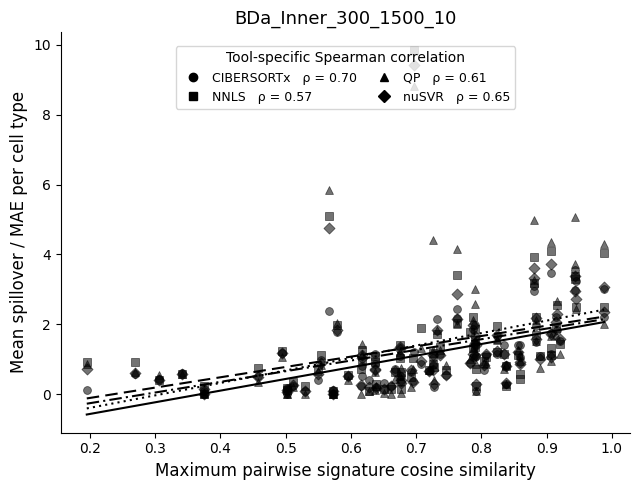

Saved merged data: COO_per_celltype_error_vs_signature_similarity/BDa_Inner_300_1500_10.spillover_vs_max_cosine.tsv
Saved plot: COO_per_celltype_error_vs_signature_similarity/BDa_Inner_300_1500_10.spillover_vs_max_cosine.by_tool.svg

Processing BDa_Outer_300_1500_10


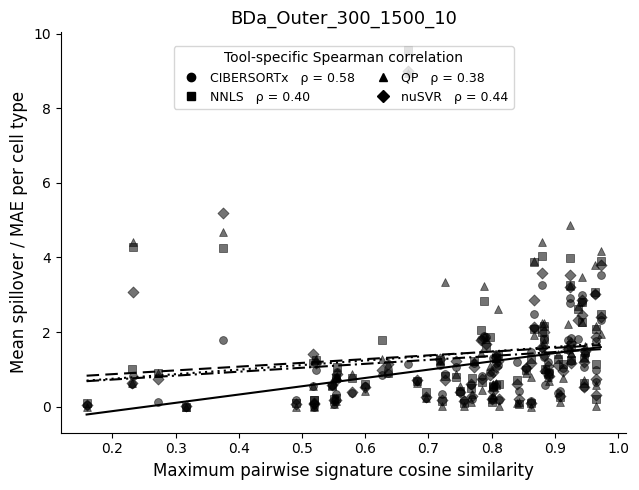

Saved merged data: COO_per_celltype_error_vs_signature_similarity/BDa_Outer_300_1500_10.spillover_vs_max_cosine.tsv
Saved plot: COO_per_celltype_error_vs_signature_similarity/BDa_Outer_300_1500_10.spillover_vs_max_cosine.by_tool.svg

Processing HBA_Inner_300_1500_10


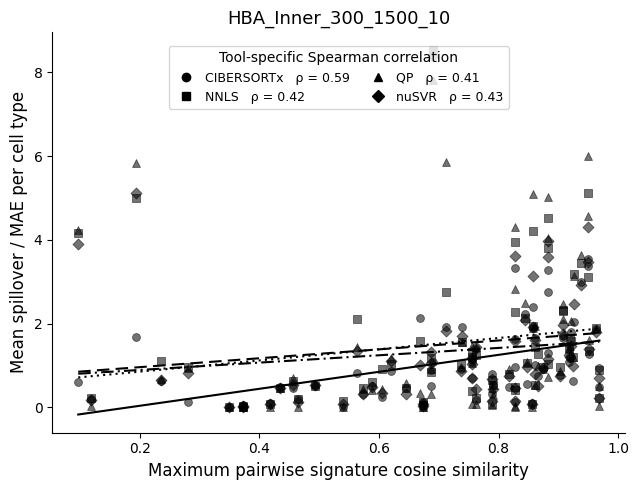

Saved merged data: COO_per_celltype_error_vs_signature_similarity/HBA_Inner_300_1500_10.spillover_vs_max_cosine.tsv
Saved plot: COO_per_celltype_error_vs_signature_similarity/HBA_Inner_300_1500_10.spillover_vs_max_cosine.by_tool.svg


,Reference,Tool,n_cell_types,spearman_rho,spearman_p,pearson_r,pearson_p
0,BDa_Inner_300_1500_10,CIBERSORTx,80,0.700788,4.591778e-13,0.644957,1.068153e-10
3,BDa_Inner_300_1500_10,nuSVR,80,0.648838,7.584343e-11,0.390596,3.409490e-04
2,BDa_Inner_300_1500_10,QP,80,0.607450,2.309021e-09,0.390998,3.357529e-04
1,BDa_Inner_300_1500_10,NNLS,80,0.574863,2.452678e-08,0.358037,1.110998e-03
4,BDa_Outer_300_1500_10,CIBERSORTx,78,0.583811,2.020270e-08,0.513896,1.493602e-06
7,BDa_Outer_300_1500_10,nuSVR,78,0.435759,6.674308e-05,0.152803,1.816827e-01
5,BDa_Outer_300_1500_10,NNLS,78,0.400577,2.789424e-04,0.137372,2.303938e-01
6,BDa_Outer_300_1500_10,QP,78,0.380724,5.846253e-04,0.154741,1.761415e-01
8,HBA_Inner_300_1500_10,CIBERSORTx,69,0.587373,1.124719e-07,0.491476,1.800578e-05
11,HBA_Inner_300_1500_10,nuSVR,69,0.429170,2.335893e-04,0.134011,2.722916e-01


In [13]:
all_merged = []
all_corr_results = []

for ref_dir, ref_name in refs:

    print(f"\nProcessing {ref_name}")

    merged, results_df = correlate_spillover_with_cosine(
        ref_dir=ref_dir,
        ref_name=ref_name
    )

    all_merged.append(merged.assign(Reference=ref_name))
    all_corr_results.append(results_df)

spillover_similarity_df = pd.concat(all_merged, ignore_index=True)
correlation_results_df = pd.concat(all_corr_results, ignore_index=True)

spillover_similarity_df.to_csv(
    os.path.join(OUT_CORR_DIR, "ALL_references.spillover_vs_max_cosine.tsv"),
    sep="\t",
    index=False
)

correlation_results_df.to_csv(
    os.path.join(OUT_CORR_DIR, "ALL_references.correlation_results_by_tool.tsv"),
    sep="\t",
    index=False
)

correlation_results_df.sort_values(
    ["Reference", "spearman_rho"],
    ascending=[True, False]
)

Matched tissues: 28


,Reference,Tool,n_tissues,spearman_rho,spearman_p,pearson_r,pearson_p
3,2Median_300_500,nuSVR,28,0.350445,0.067503,0.296477,0.125532
0,2Median_300_500,CIBERSORTx,28,0.339767,0.076900,0.277534,0.152751
1,2Median_300_500,NNLS,28,0.128170,0.515705,0.187575,0.339163
2,2Median_300_500,QP,28,0.082409,0.676753,0.151863,0.440448


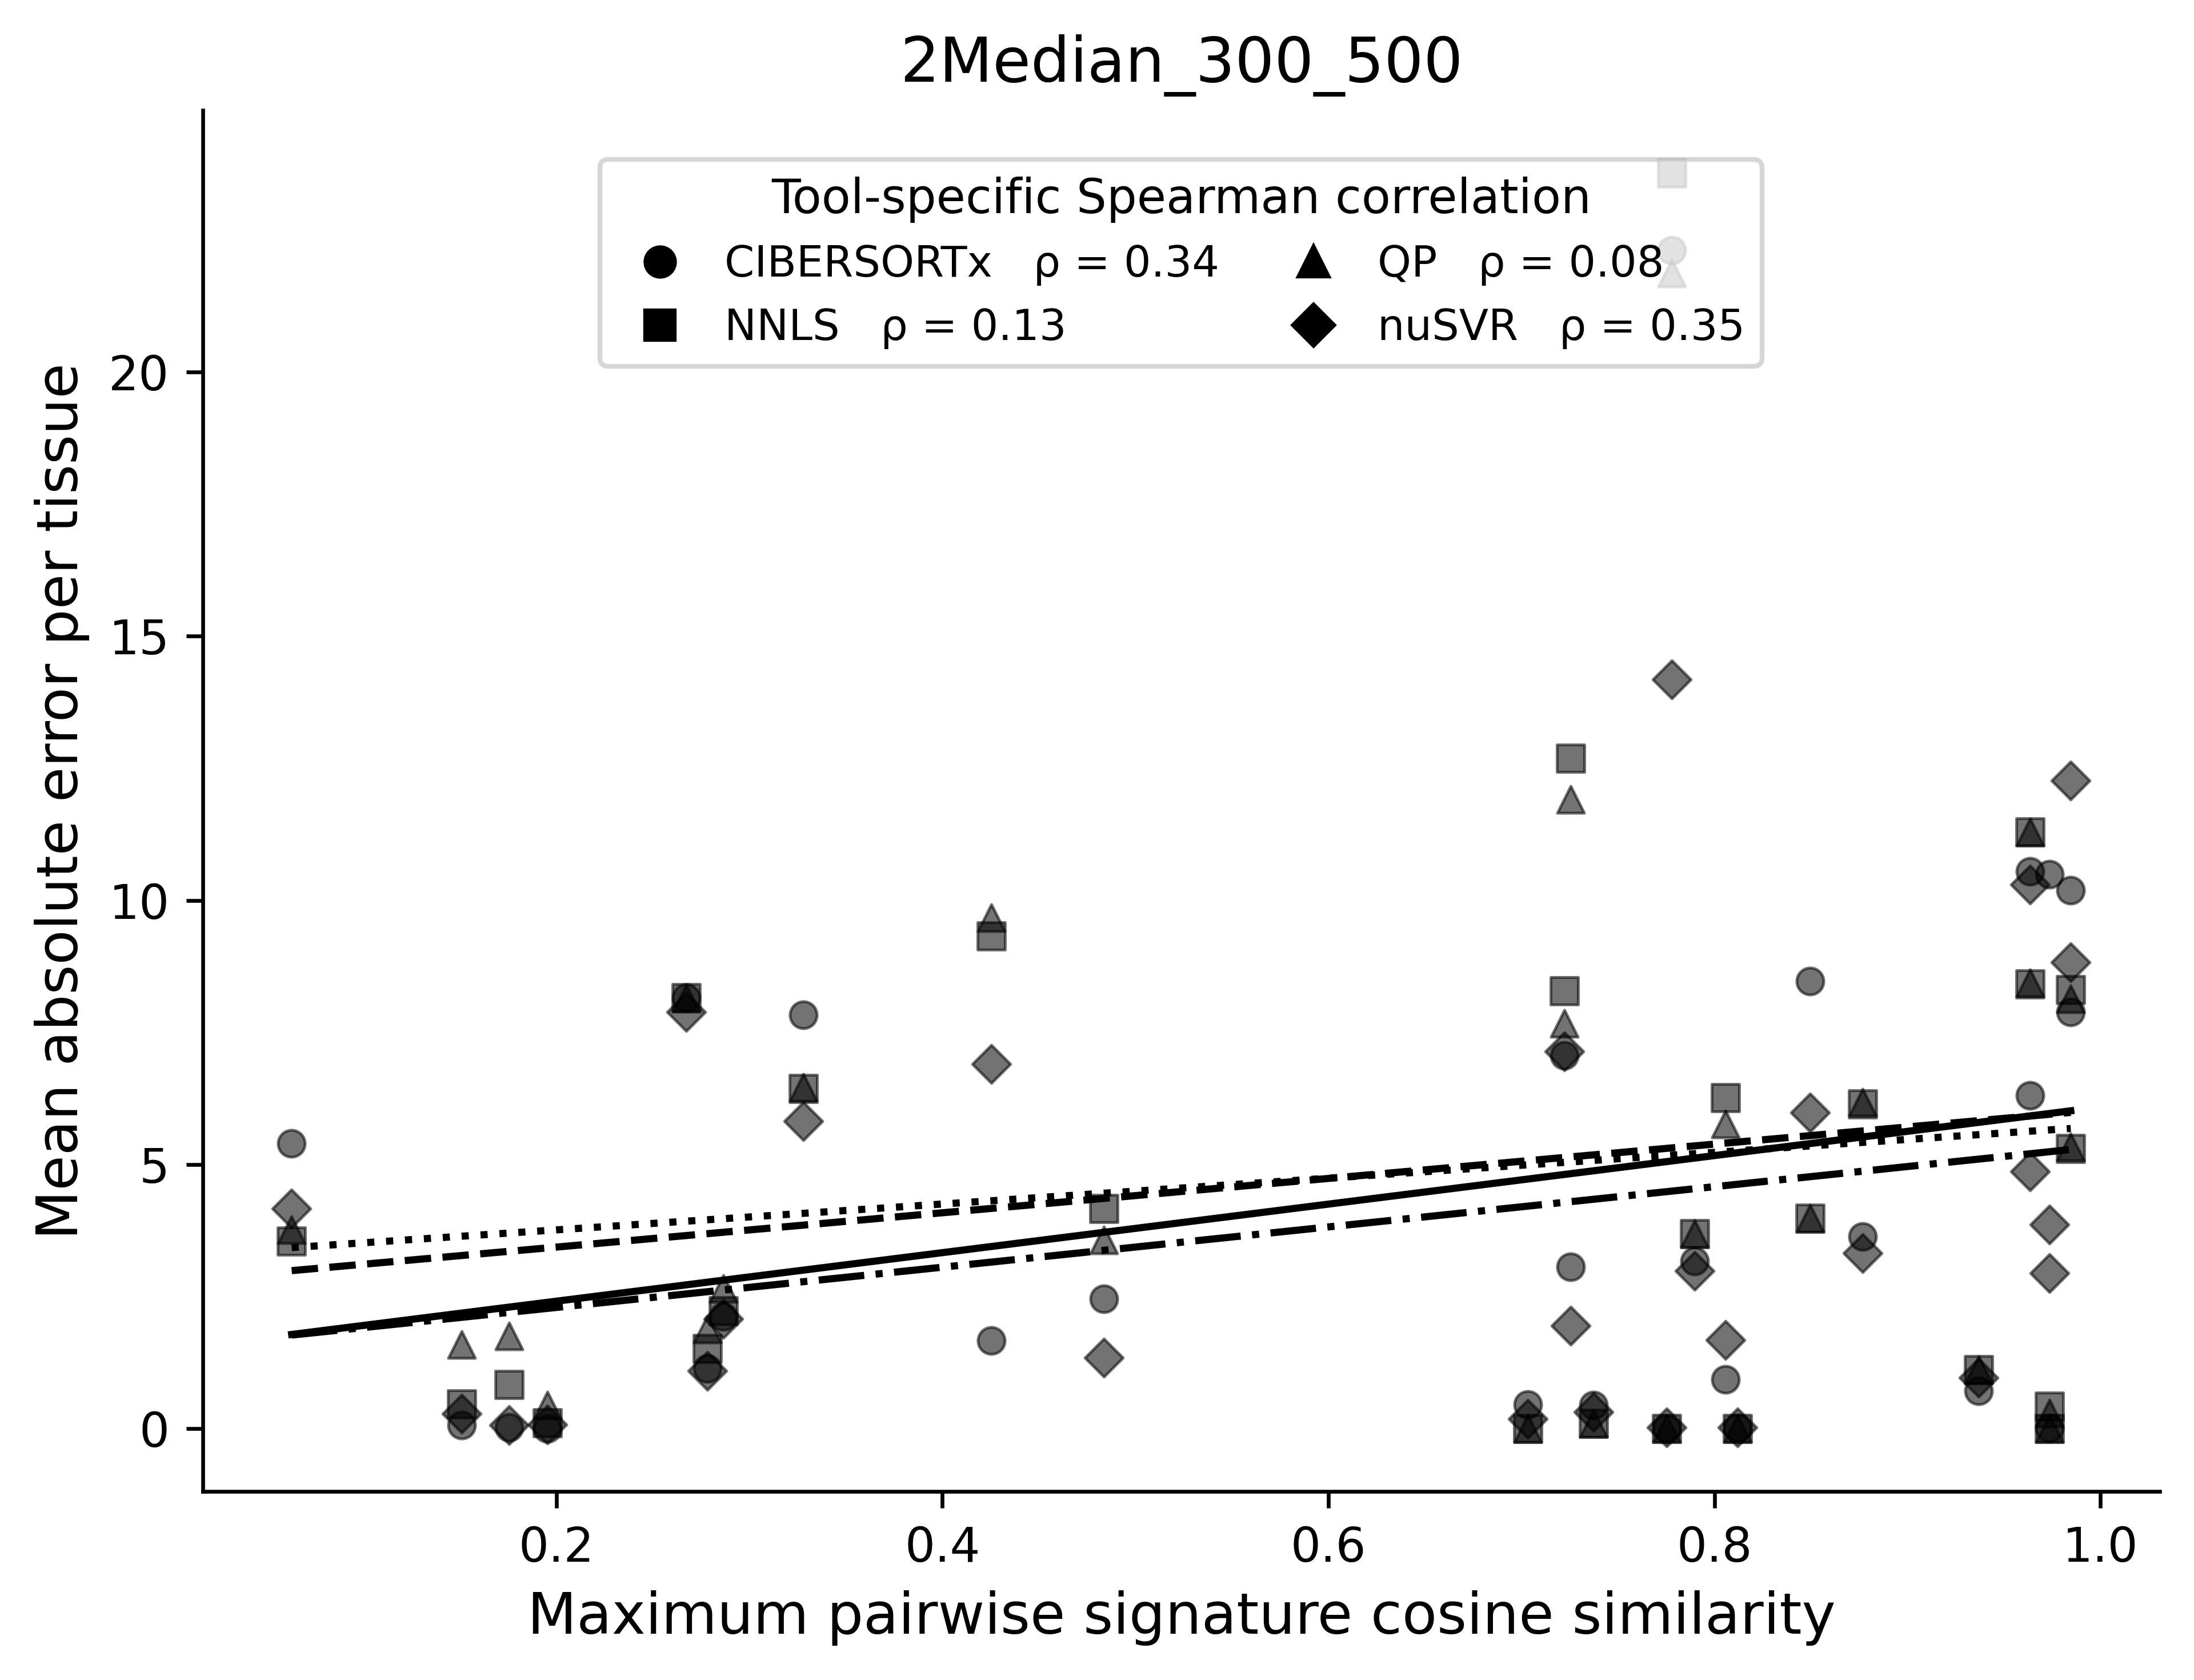

Saved per-tissue plot: TOO_per_tissue_error_vs_signature_similarity/2Median_300_500.per_tissue_error_vs_max_cosine.by_tool.svg


In [14]:
RELEVANT_TOOLS = ["CIBERSORTx", "NNLS", "QP", "nuSVR"]

BASE_DIR = "TOO-Decon/"
ERROR_FILE = os.path.join(BASE_DIR, "merged_Results_Spillover_Random_TOOv2.txt")

TOO_COSINE_DIR = "TOO_Matrices_Cosine_Similarity"

OUT_CORR_DIR = "TOO_per_tissue_error_vs_signature_similarity"
os.makedirs(OUT_CORR_DIR, exist_ok=True)

REFERENCE_MATRIX = "2Median_300_500"

tissue_cols = [
    'Adipose', 'Adrenal gland', 'Arteries', 'Bladder', 'Brain', 'Breast',
    'Colon', 'Esophagus', 'FemaleReproductive', 'Fibroblasts', 'Heart',
    'Kidney', 'Liver', 'Lung', 'Lymphocytes', 'MuscleSkeletal',
    'NerveTibial', 'Pancreas', 'Pituitary', 'Prostate', 'SalivaryGland',
    'Skin', 'SmallIntestine', 'Spleen', 'Stomach', 'Testis', 'Thyroid',
    'Whole blood'
]

rename_map = {
    "SmallIntestine": "Small intestine",
    "SalivaryGland": "Salivary gland",
    "FemaleReproductive": "Female reproductive",
    "NerveTibial": "Tibial nerve",
    "MuscleSkeletal": "Skeletal muscle",
    "Pituitary": "Pituitary gland"
}

def find_too_cosine_summary(matrix_key):
    files = glob.glob(os.path.join(TOO_COSINE_DIR, "*.closest_matches.tsv"))

    matches = [
        f for f in files
        if matrix_key in os.path.basename(f)
    ]

    if len(matches) == 0:
        raise FileNotFoundError(
            f"No TOO closest_matches file found for {matrix_key}"
        )

    if len(matches) > 1:
        print("Multiple matches found; using first:")
        for m in matches:
            print(" ", m)

    return matches[0]

# -------------------------
# Load per-tissue error
# -------------------------

df = pd.read_csv(ERROR_FILE, sep="\t")

df_filtered = df[
    (df["Matrix"] == REFERENCE_MATRIX) &
    (df["Method"].isin(RELEVANT_TOOLS))
].copy()

error_long = df_filtered.melt(
    id_vars=["Method", "Matrix"],
    value_vars=tissue_cols,
    var_name="tissue_raw",
    value_name="MAE"
)

error_long["Tissue"] = error_long["tissue_raw"].replace(rename_map)

error_mean = (
    error_long
    .groupby(["Method", "Tissue"], as_index=False)["MAE"]
    .mean()
)

# -------------------------
# Load max cosine similarity
# -------------------------

cosine_file = find_too_cosine_summary(REFERENCE_MATRIX)
cosine_df = pd.read_csv(cosine_file, sep="\t")

cosine_df = cosine_df.rename(columns={"cell_type": "Tissue"})
cosine_df["Tissue"] = cosine_df["Tissue"].replace(rename_map)

# -------------------------
# Collapse cosine tissues to match error tissue definitions
# -------------------------

# ColonSigmoid + ColonTransverse -> Colon
colon_rows = cosine_df[
    cosine_df["Tissue"].isin(["ColonSigmoid", "ColonTransverse"])
]

if len(colon_rows) > 0:

    colon_combined = pd.DataFrame({
        "Tissue": ["Colon"],
        "max_cosine_similarity": [colon_rows["max_cosine_similarity"].max()],
        "mean_cosine_similarity": [colon_rows["mean_cosine_similarity"].mean()],
        "closest_match": ["collapsed: ColonSigmoid/ColonTransverse"]
    })

    cosine_df = cosine_df[
        ~cosine_df["Tissue"].isin(["ColonSigmoid", "ColonTransverse"])
    ]

    cosine_df = pd.concat(
        [cosine_df, colon_combined],
        ignore_index=True
    )


# Esophagus + EsophagusMucosa -> Esophagus
eso_rows = cosine_df[
    cosine_df["Tissue"].isin(["Esophagus", "EsophagusMucosa"])
]

if len(eso_rows) > 0:

    eso_combined = pd.DataFrame({
        "Tissue": ["Esophagus"],
        "max_cosine_similarity": [eso_rows["max_cosine_similarity"].max()],
        "mean_cosine_similarity": [eso_rows["mean_cosine_similarity"].mean()],
        "closest_match": ["collapsed: Esophagus/EsophagusMucosa"]
    })

    cosine_df = cosine_df[
        ~cosine_df["Tissue"].isin(["Esophagus", "EsophagusMucosa"])
    ]

    cosine_df = pd.concat(
        [cosine_df, eso_combined],
        ignore_index=True
    )

merged = error_mean.merge(
    cosine_df[
        [
            "Tissue",
            "max_cosine_similarity",
            "mean_cosine_similarity",
            "closest_match"
        ]
    ],
    on="Tissue",
    how="inner"
)

print("Matched tissues:", merged["Tissue"].nunique())
merged.head()

# -------------------------
# Correlations per tool
# -------------------------

corr_results = []

for tool, sub in merged.groupby("Method"):

    pearson_r, pearson_p = pearsonr(
        sub["max_cosine_similarity"],
        sub["MAE"]
    )

    spearman_rho, spearman_p = spearmanr(
        sub["max_cosine_similarity"],
        sub["MAE"]
    )

    corr_results.append({
        "Reference": REFERENCE_MATRIX,
        "Tool": tool,
        "n_tissues": sub["Tissue"].nunique(),
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p
    })

corr_results_df = pd.DataFrame(corr_results)

# Pretty table: correlation per tool for this tissue reference
corr_results_df = corr_results_df.sort_values(
    "spearman_rho",
    ascending=False
)

display(corr_results_df)

corr_results_df.to_csv(
    os.path.join(
        OUT_CORR_DIR,
        f"{REFERENCE_MATRIX}.per_tissue_error_vs_max_cosine.correlations.tsv"
    ),
    sep="\t",
    index=False
)

corr_results_df.sort_values("pearson_r", ascending=False)

plot_df = merged[
    merged["Method"].isin(RELEVANT_TOOLS)
].copy()

tool_order_present = [
    tool
    for tool in RELEVANT_TOOLS
    if tool in plot_df["Method"].unique()
]

tool_markers = {
    "CIBERSORTx": "o",
    "NNLS": "s",
    "QP": "^",
    "nuSVR": "D",
}

tool_linestyles = {
    "CIBERSORTx": "-",
    "NNLS": "--",
    "QP": ":",
    "nuSVR": "-.",
}

fig, ax = plt.subplots(
    figsize=(6.5, 5),
    dpi=600
)

legend_handles = []

for tool in tool_order_present:

    sub = (
        plot_df[
            plot_df["Method"] == tool
        ]
        .dropna(
            subset=[
                "max_cosine_similarity",
                "MAE"
            ]
        )
        .copy()
    )

    if sub.empty:
        continue

    # Tool-specific Spearman correlation
    if (
        sub.shape[0] >= 3
        and sub["max_cosine_similarity"].nunique() > 1
        and sub["MAE"].nunique() > 1
    ):
        rho, p_value = spearmanr(
            sub["max_cosine_similarity"],
            sub["MAE"]
        )

        correlation_label = (
            f"{tool}   ρ = {rho:.2f}"
        )
    else:
        correlation_label = (
            f"{tool}   ρ unavailable"
        )

    # Black points with tool-specific marker shapes
    ax.scatter(
        sub["max_cosine_similarity"],
        sub["MAE"],
        marker=tool_markers[tool],
        s=32,
        facecolor="black",
        edgecolor="black",
        linewidth=0.6,
        alpha=0.55,
        zorder=3
    )

    # Tool-specific fitted linear trend
    if (
        sub.shape[0] >= 2
        and sub["max_cosine_similarity"].nunique() > 1
    ):
        sns.regplot(
            data=sub,
            x="max_cosine_similarity",
            y="MAE",
            scatter=False,
            ci=None,
            color="black",
            line_kws={
                "linewidth": 1.5,
                "linestyle": tool_linestyles[tool]
            },
            ax=ax
        )

    # Marker-only legend handle
    legend_handles.append(
        Line2D(
            [0],
            [0],
            marker=tool_markers[tool],
            linestyle="",
            color="black",
            markerfacecolor="black",
            markeredgecolor="black",
            markersize=6,
            label=correlation_label
        )
    )

ax.set_xlabel(
    "Maximum pairwise signature cosine similarity"
)

ax.set_ylabel(
    "Mean absolute error per tissue"
)

ax.set_title(
    REFERENCE_MATRIX
)

ax.legend(
    handles=legend_handles,
    title="Tool-specific Spearman correlation",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    frameon=True,
    fontsize=9,
    title_fontsize=10,
    ncol=2,
    columnspacing=1.2,
    handletextpad=0.5,
    borderpad=0.4
)

sns.despine(ax=ax)
fig.tight_layout()

per_tissue_svg = os.path.join(
    OUT_CORR_DIR,
    f"{REFERENCE_MATRIX}.per_tissue_error_vs_max_cosine.by_tool.svg"
)

fig.savefig(
    per_tissue_svg,
    format="svg",
    bbox_inches="tight",
    facecolor="white",
    transparent=False
)

plt.show()
plt.close(fig)

print(f"Saved per-tissue plot: {per_tissue_svg}")

In [15]:
error_tissues = set(error_mean["Tissue"].unique())
cosine_tissues = set(cosine_df["Tissue"].unique())

print("In error file but not cosine file:")
print(sorted(error_tissues - cosine_tissues))

print("\nIn cosine file but not error file:")
print(sorted(cosine_tissues - error_tissues))

In error file but not cosine file:
[]

In cosine file but not error file:
[]
